<h5> Box Cox and Yeo Johnson will be used here </h5>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  r2_score


In [5]:
df = pd.read_csv('concrete_data.csv')


In [6]:
df.head(4)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [8]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
df.shape

(1030, 9)

In [10]:
df.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [11]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [12]:
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [13]:
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3
...,...,...,...,...,...,...,...,...
87,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,3
330,246.8,0.0,125.1,143.3,12.0,1086.8,800.9,14
466,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,100
121,475.0,118.8,0.0,181.1,8.9,852.1,781.5,28


In [16]:
y_train

995    27.68
507    62.05
334    23.80
848    33.40
294     7.40
       ...  
87     24.40
330    42.22
466    33.56
121    68.30
860    38.46
Name: Strength, Length: 824, dtype: float64

In [17]:
print(X_train.shape)


(824, 8)


In [18]:
X_test.shape

(206, 8)

In [19]:
y_train.shape

(824,)

In [20]:
y_test.shape

(206,)

In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.627553179231485

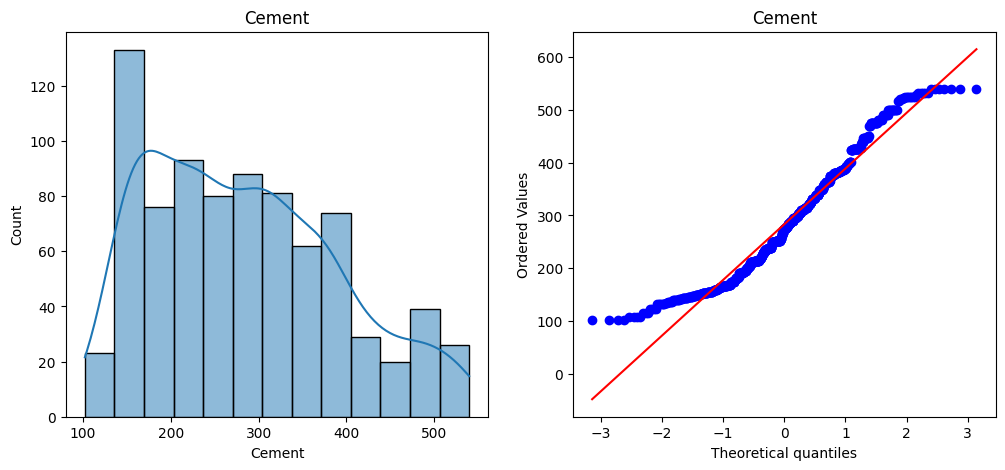

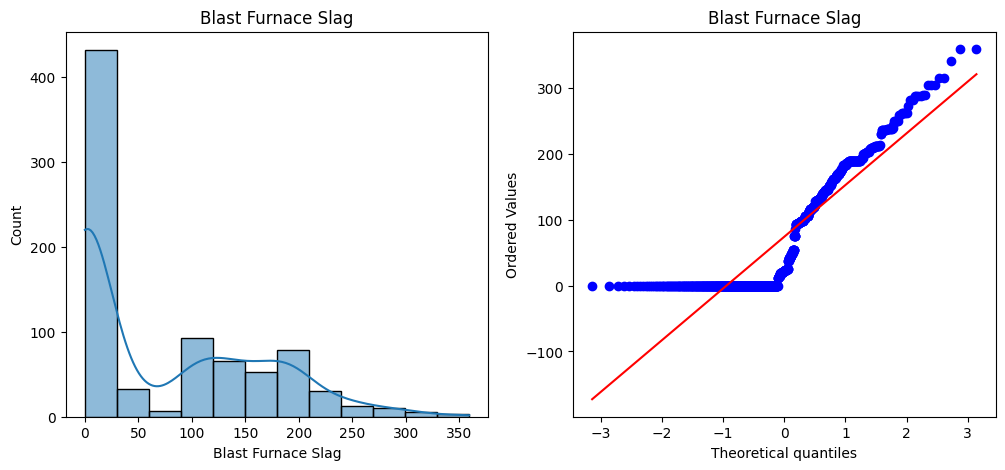

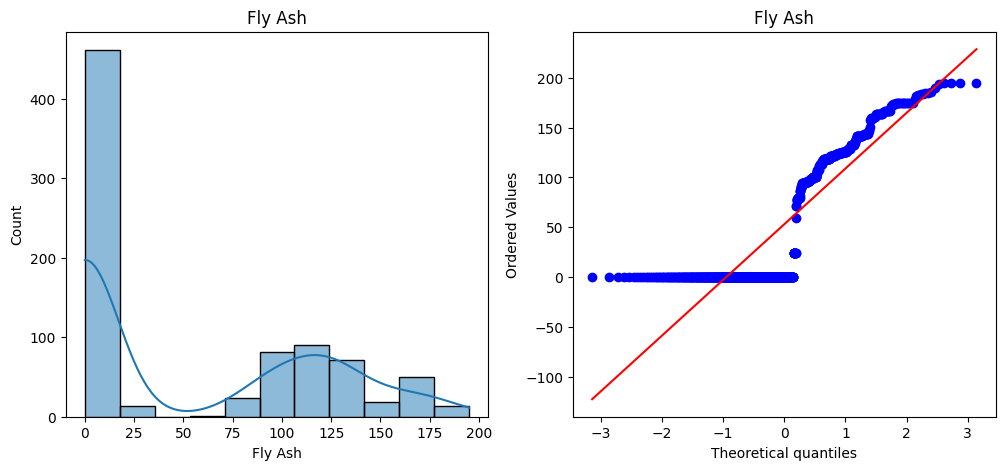

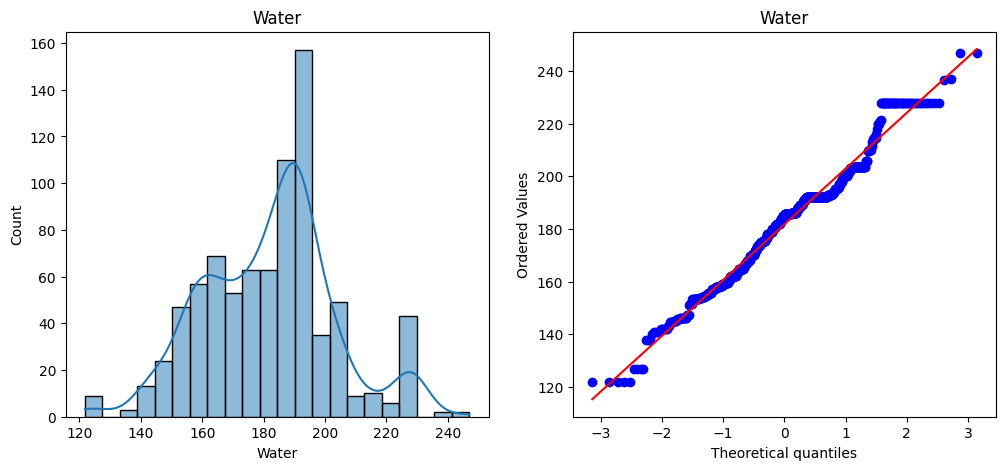

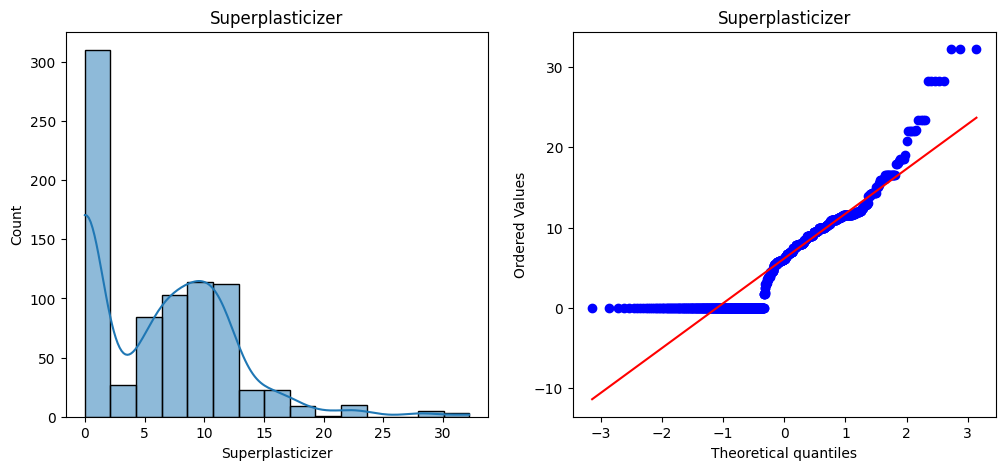

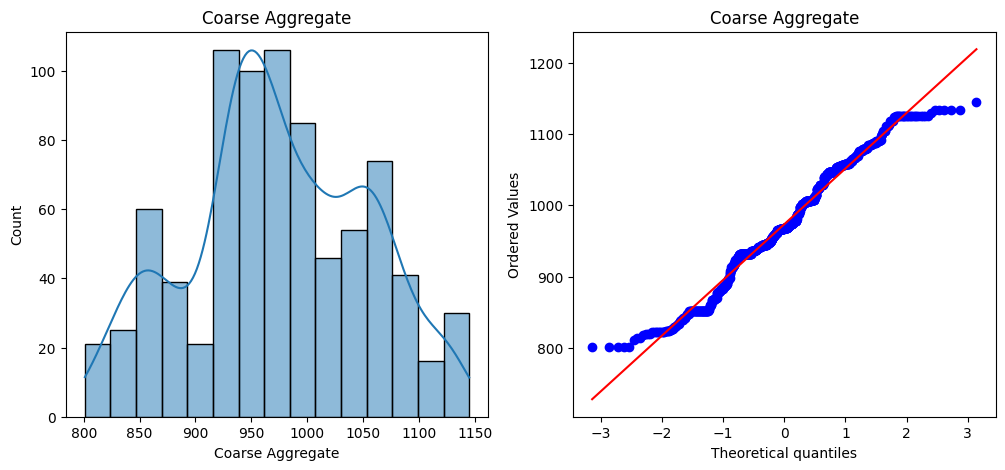

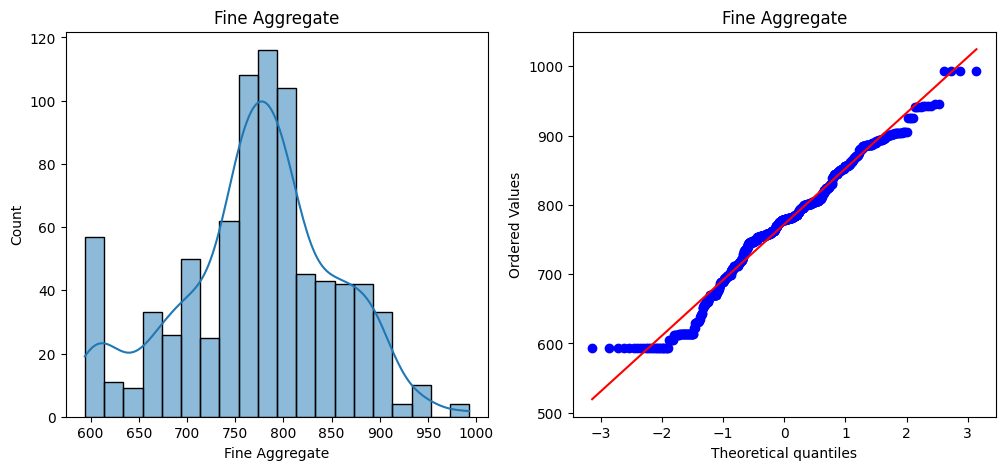

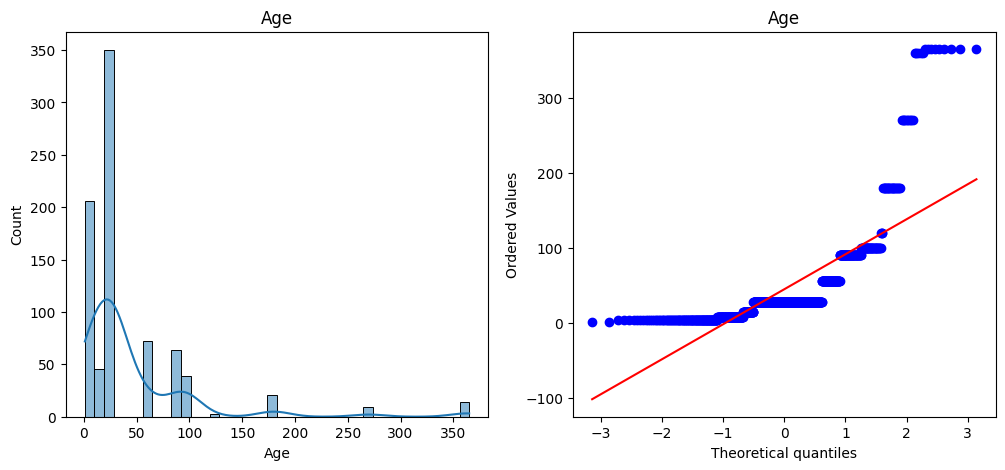

In [22]:
for col in X_train.columns:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True)
    plt.title(col)
    
    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)
    plt.show()
    

In [23]:
pt = PowerTransformer(method='box-cox')
X_train_transformed =  pt.fit_transform(X_train+0.0000001)
X_test_transformed = pt.transform(X_test+0.0000001)
pd.DataFrame(X_train_transformed, columns=X_train.columns)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,-1.279751,0.952465,1.127922,-0.301920,0.882668,-0.262500,-0.677568,0.106010
1,1.244706,0.724950,1.136408,-0.165055,0.751714,-1.912728,-0.314062,0.106010
2,0.079842,-1.086310,1.130914,-1.047291,0.786233,1.018407,0.025957,-1.675970
3,-0.145641,0.900610,1.099884,0.581224,0.738115,-1.750779,0.583253,0.106010
4,-1.131044,0.801340,1.132465,-1.105297,0.806139,1.368575,0.262623,-1.675970
...,...,...,...,...,...,...,...,...
819,0.183601,0.989009,-0.887244,-1.769923,0.814504,0.390563,0.358776,-1.675970
820,-0.198733,-1.086310,1.132886,-1.839129,0.830446,1.445973,0.322797,-0.475625
821,-0.844517,-1.086310,1.132939,-0.706089,0.786233,1.345367,0.297157,1.246733
822,1.565624,0.925077,-0.887244,-0.019311,0.762077,-1.537255,0.076211,0.106010


In [24]:
lr = LinearRegression()
lr.fit(X_train_transformed, y_train)
y_pred = lr.predict(X_test_transformed)
r2_score(y_test,y_pred)


0.8042534505737435

After Power Transformation: 


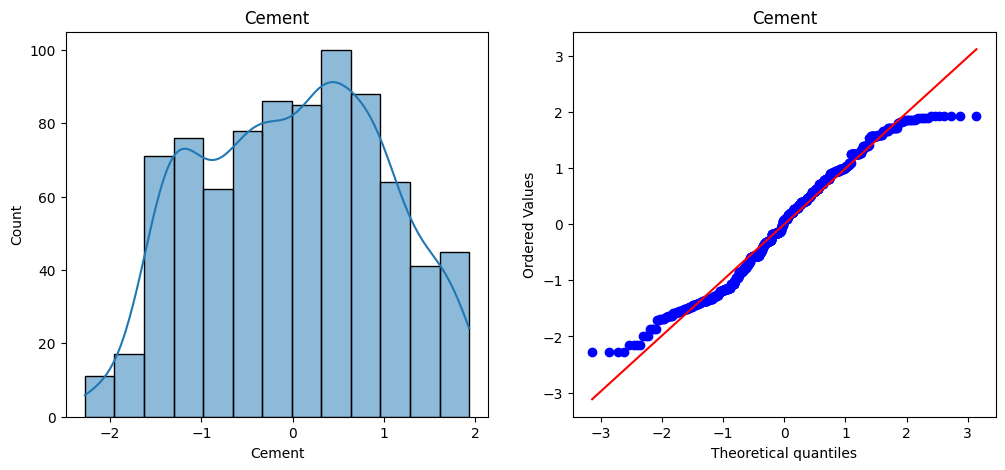

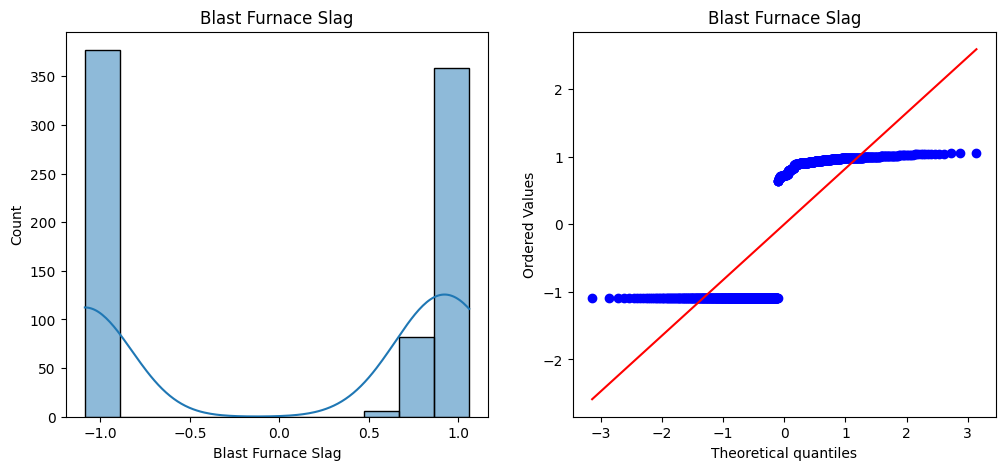

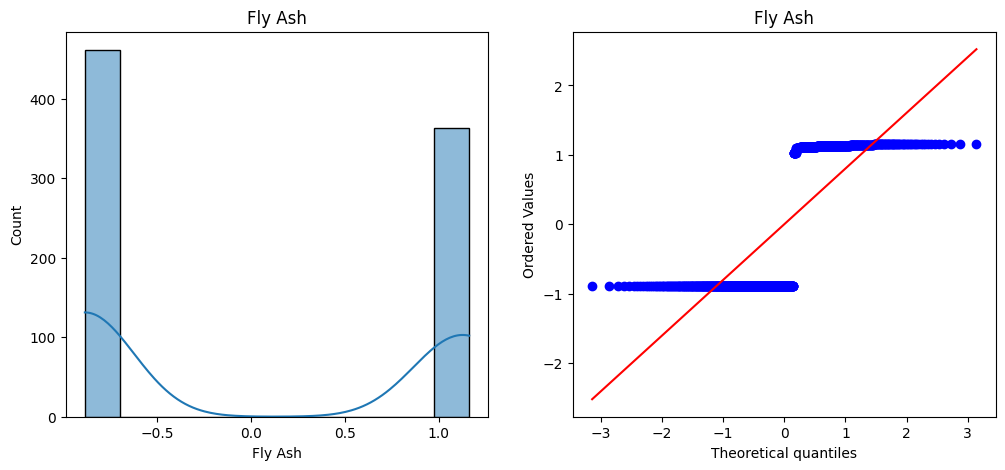

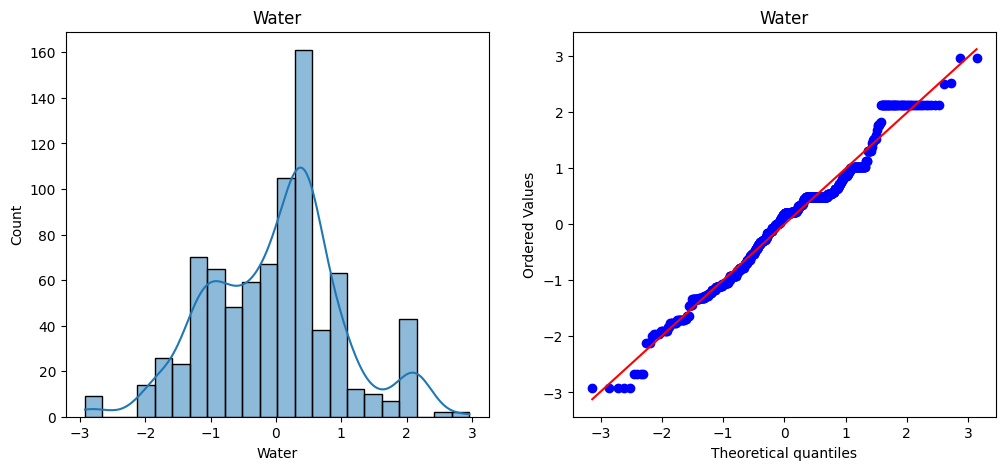

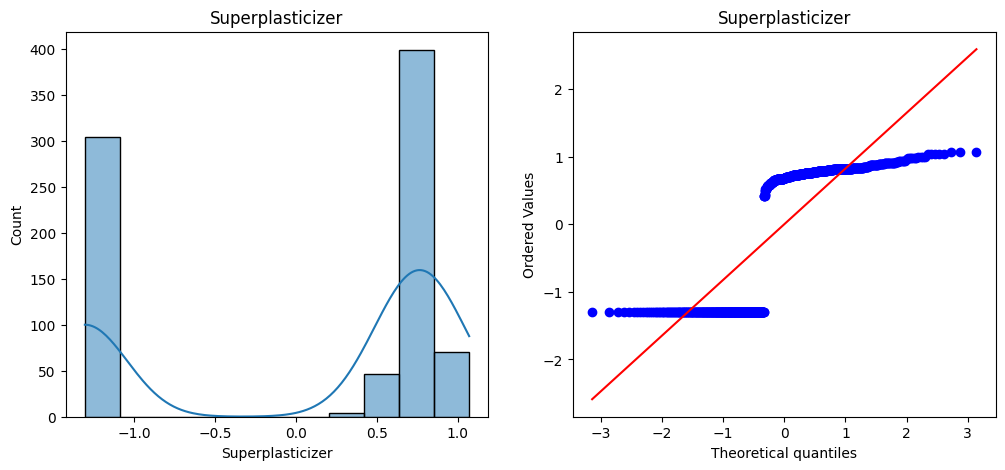

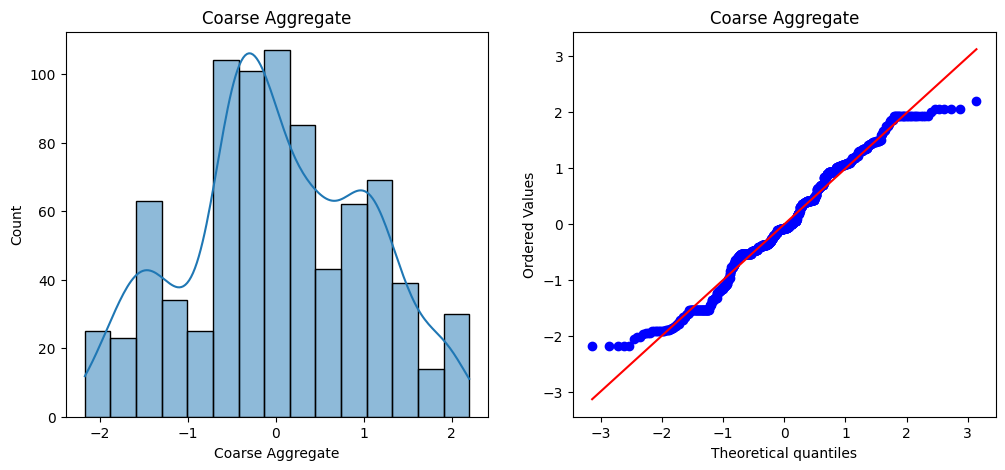

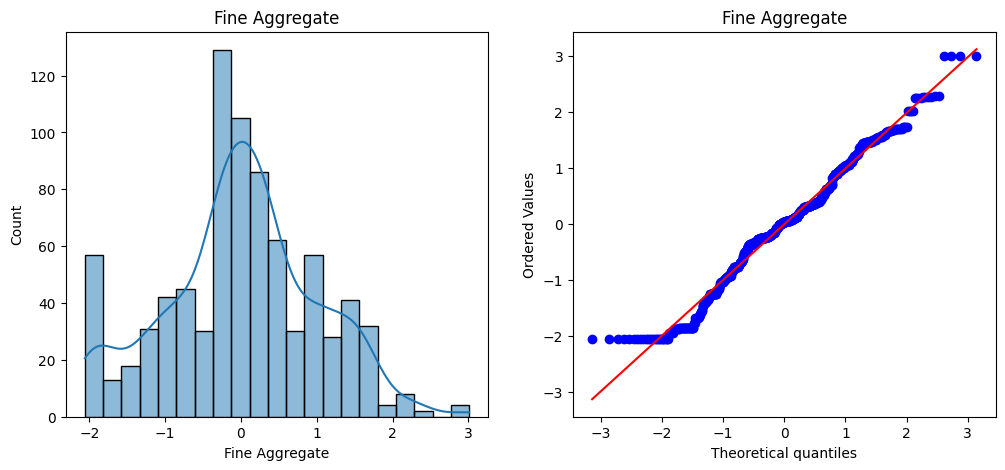

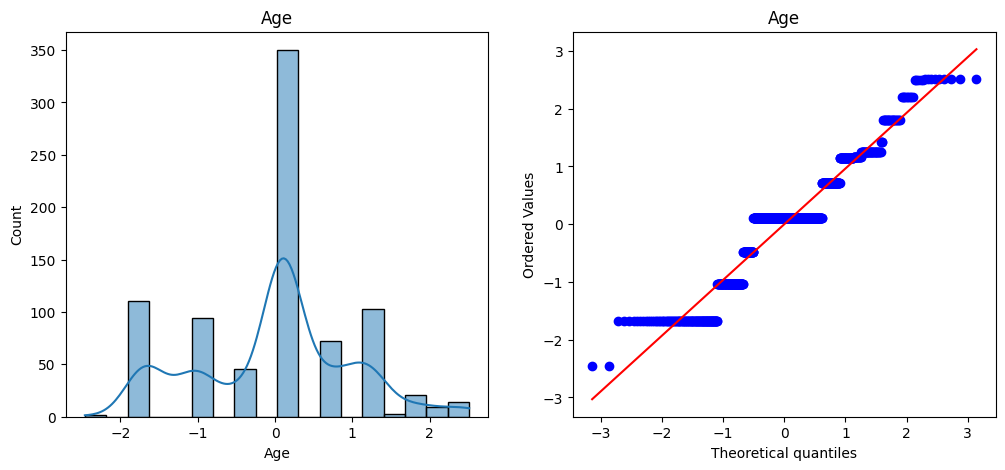

In [25]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
print("After Power Transformation: ")
for i in X_train_transformed.columns:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(X_train_transformed[i], kde=True)
    plt.title(i)
    
    plt.subplot(122)
    stats.probplot(X_train_transformed[i], dist="norm", plot=plt)
    plt.title(i)
    plt.show()  

<h3> Using Yeo Johnson Power Transform </h3>

In [26]:
pt2 = PowerTransformer(method='yeo-johnson')
X_train_transformed2 =  pt2.fit_transform(X_train)
X_test_transformed2 = pt2.transform(X_test)
pd.DataFrame(X_train_transformed2, columns=X_train.columns)
lr = LinearRegression()
lr.fit(X_train_transformed2, y_train)
y_pred = lr.predict(X_test_transformed2)
r2_score(y_test,y_pred) 

0.8161906508973581

In [27]:
cross_val = cross_val_score(lr, X_train_transformed2, y_train, cv=5, scoring='r2')
print("Cross Validation Scores: ", cross_val)

Cross Validation Scores:  [0.76407188 0.76308498 0.83075827 0.81415039 0.79882557]


After Power Transformation: 


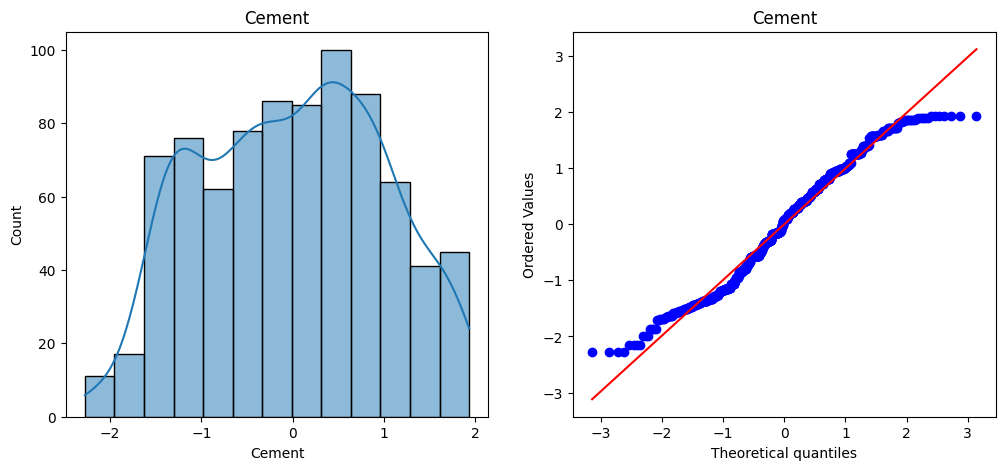

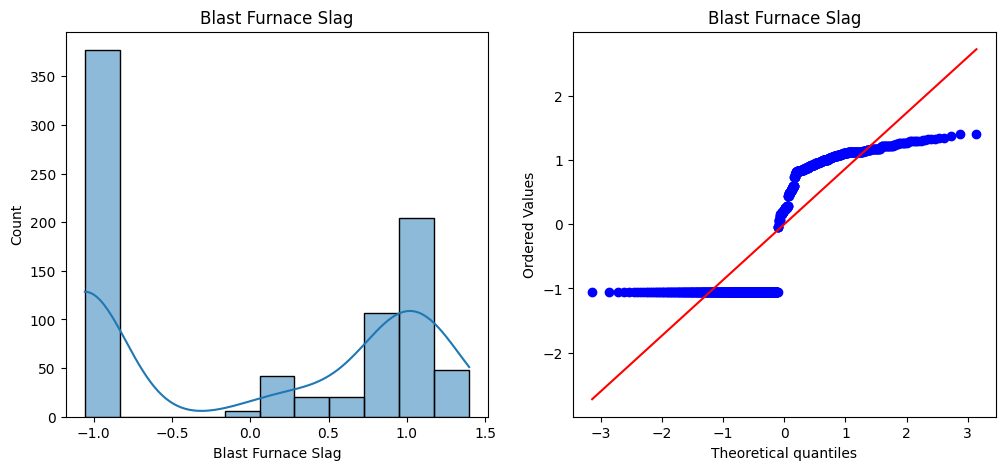

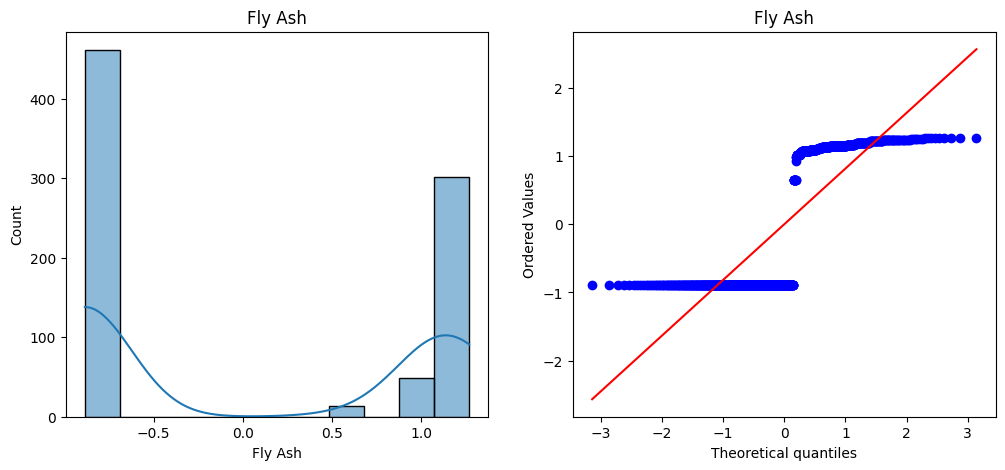

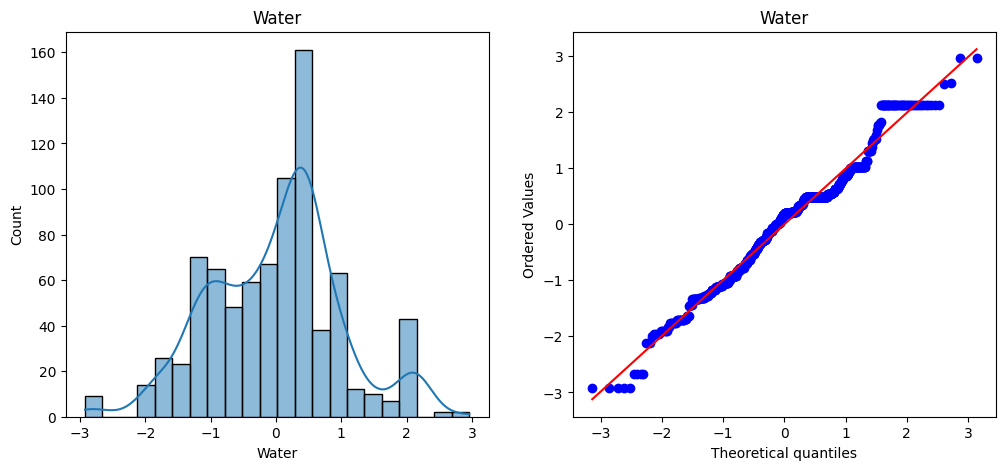

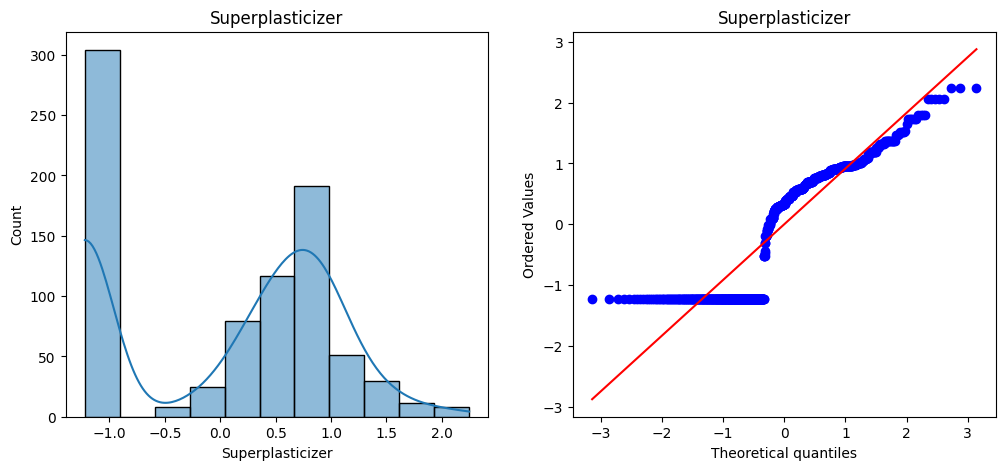

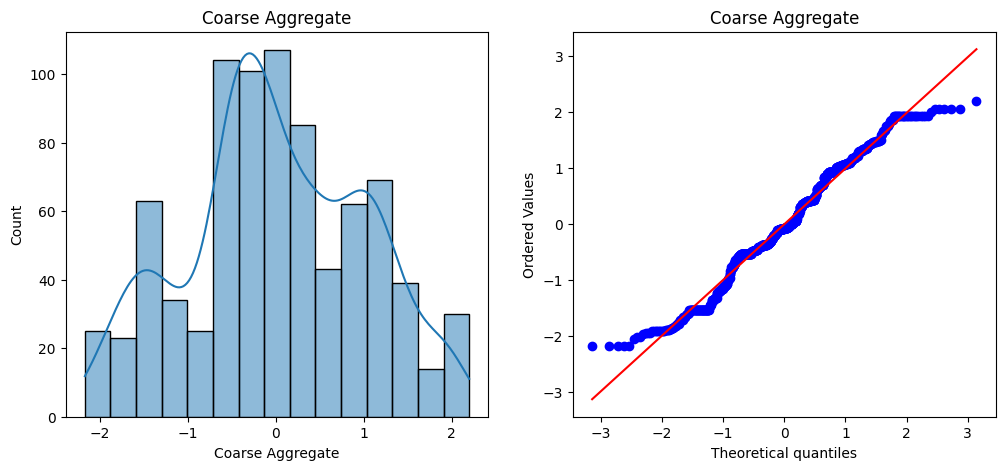

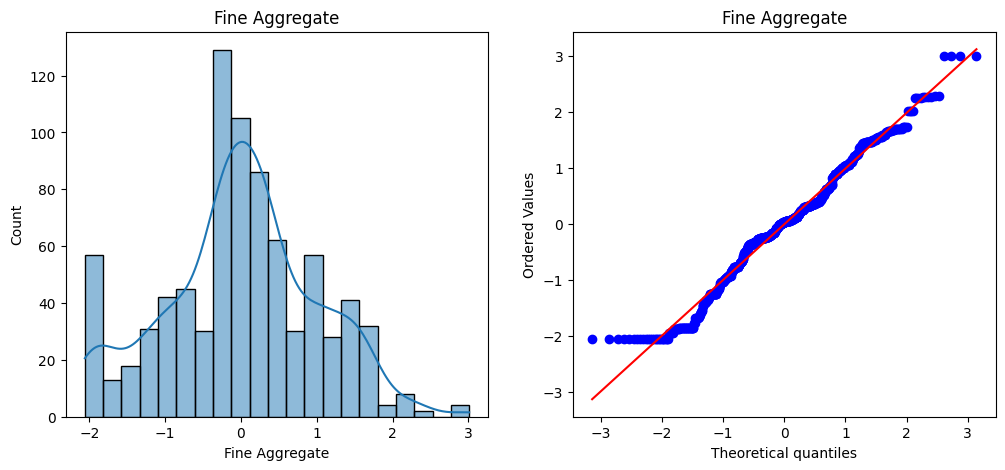

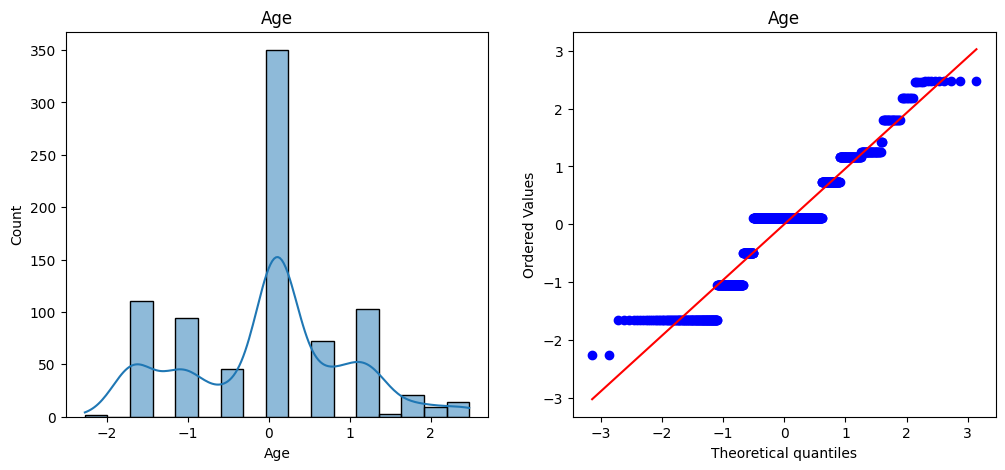

In [28]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2, columns=X_train.columns)
print("After Power Transformation: ")
for i in X_train_transformed2.columns:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(X_train_transformed2[i], kde=True)
    plt.title(i)
    
    plt.subplot(122)
    stats.probplot(X_train_transformed2[i], dist="norm", plot=plt)
    plt.title(i)
    plt.show()      

In [29]:
pt.lambdas_

array([ 0.17702536,  0.02276661, -0.03463487,  0.77268169,  0.08714096,
        1.12981321,  1.78201829,  0.06663097])

In [30]:
pt

,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'box-cox'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True


In [31]:
pt.lambdas_

array([ 0.17702536,  0.02276661, -0.03463487,  0.77268169,  0.08714096,
        1.12981321,  1.78201829,  0.06663097])

In [32]:
# calculate lambdas_ for both methods
pd.DataFrame({'Columns': X_train.columns, 'Box-Cox Lambda': pt.lambdas_, 'Yeo-Johnson Lambda': pt2.lambdas_})


,Columns,Box-Cox Lambda,Yeo-Johnson Lambda
0,Cement,0.177025,0.174348
1,Blast Furnace Slag,0.022767,0.015715
2,Fly Ash,-0.034635,-0.161447
3,Water,0.772682,0.771307
4,Superplasticizer,0.087141,0.253935
5,Coarse Aggregate,1.129813,1.130050
6,Fine Aggregate,1.782018,1.783100
7,Age,0.066631,0.019885


In [33]:
cement_lambda = 0.177025
blast_furnace_slag_lambda = 0.022
fly_ash_lambda = -0.03
water_lambda = 0.77
superplasticizer_lambda = 0.08
coarse_lambda = 1.12
fine_lambda = 1.78


In [34]:
df.head(4)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05


In [38]:
lambda_age = 0.066631

df['Age_L'] = ((df['Age']**lambda_age) - 1) / (lambda_age)
df['Cement_L'] = ((df['Cement']**cement_lambda) - 1) / (cement_lambda)
df['Blast Furnace Slag L'] = ((df['Blast Furnace Slag']**blast_furnace_slag_lambda) - 1) / (blast_furnace_slag_lambda)
df['Fly Ash L'] = ((df['Fly Ash']+0.0001)**fly_ash_lambda - 1) / (fly_ash_lambda)
df['Water L'] = ((df['Water']**water_lambda) - 1) / (water_lambda)
df['Superplasticizer L'] = ((df['Superplasticizer']**superplasticizer_lambda) - 1) / (superplasticizer_lambda)
df['Coarse Aggregate L'] = ((df['Coarse Aggregate']**coarse_lambda) - 1) / (coarse_lambda)
df['Fine Aggregate L'] = ((df['Fine Aggregate']**fine_lambda) - 1) / (fine_lambda)


    

In [ ]:
# Fly Ash L = ((df['Fly Ash']**fly_ash_lambda) - 1) / (fly_ash_lambda) will generate output inf because fly_ash_lambda is negative. To avoid this, we can add a small constant to the 'Fly Ash' column before applying the transformation. For example:

In [39]:
df_new = df[[
    'Age_L',
    'Cement_L',
    'Blast Furnace Slag L',
    'Fly Ash L',
    'Water L',
    'Superplasticizer L',
    'Coarse Aggregate L',
    'Fine Aggregate L'
]]

In [40]:
df_new.head(4)

,Age_L,Cement_L,Blast Furnace Slag L,Fly Ash L,Water L,Superplasticizer L,Coarse Aggregate L,Fine Aggregate L
0,3.731093,11.556584,-45.454545,-10.608558,63.989670,0.95071,2136.376786,61218.281067
1,3.731093,11.556584,-45.454545,-10.608558,63.989670,0.95071,2170.931663,61218.281067
2,6.785515,10.141205,5.240001,-10.608558,83.642639,-12.50000,1889.394367,48631.185060
3,7.227722,10.141205,5.240001,-10.608558,83.642639,-12.50000,1889.394367,48631.185060


In [37]:
df_new.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age_L                 1030 non-null   float64
 1   Cement_L              1030 non-null   float64
 2   Blast Furnace Slag L  1030 non-null   float64
 3   Fly Ash L             1030 non-null   float64
 4   Water L               1030 non-null   float64
 5   Superplasticizer L    1030 non-null   float64
 6   Coarse Aggregate L    1030 non-null   float64
 7   Fine Aggregate L      1030 non-null   float64
dtypes: float64(8)
memory usage: 64.5 KB


In [41]:
x_train, x_test, Y_train, Y_test = train_test_split(df_new,df['Strength'], test_size=0.2, random_state=42)

In [42]:
lr = LinearRegression()
lr.fit(x_train, Y_train)
y_pred = lr.predict(x_test)
r2_score(Y_test,y_pred)

0.8019900206615513

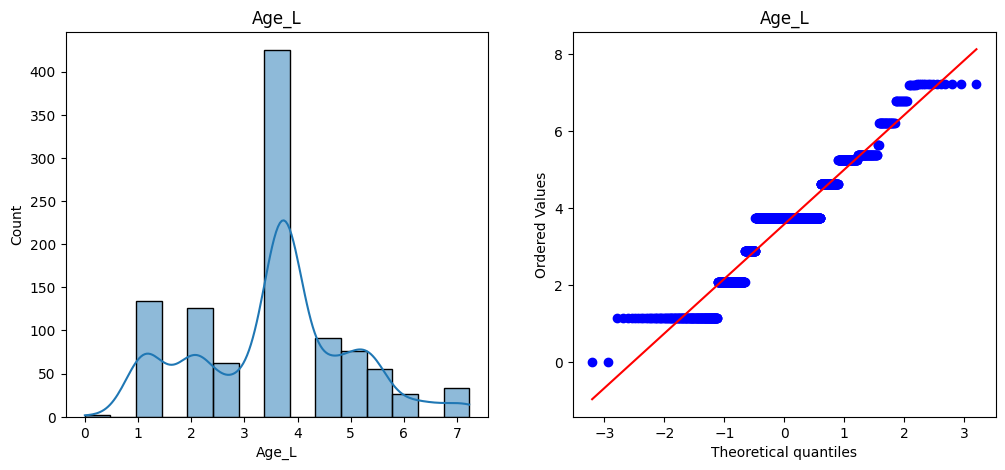

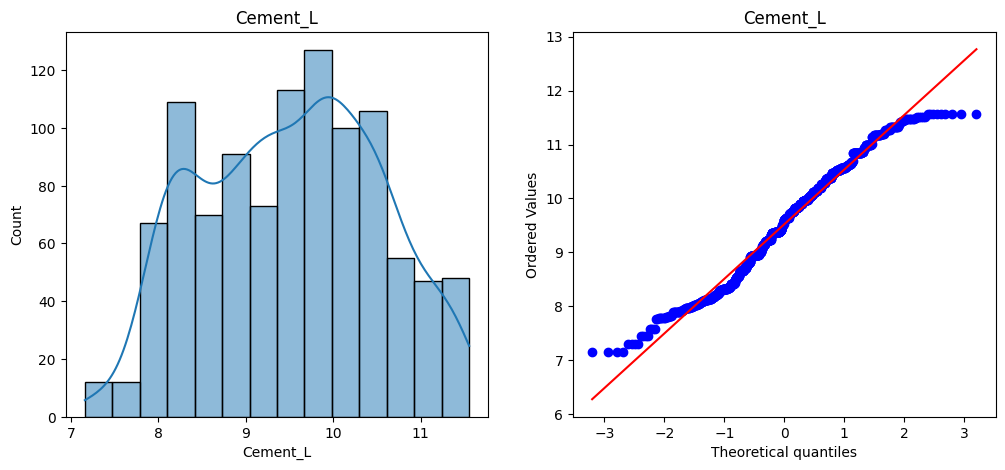

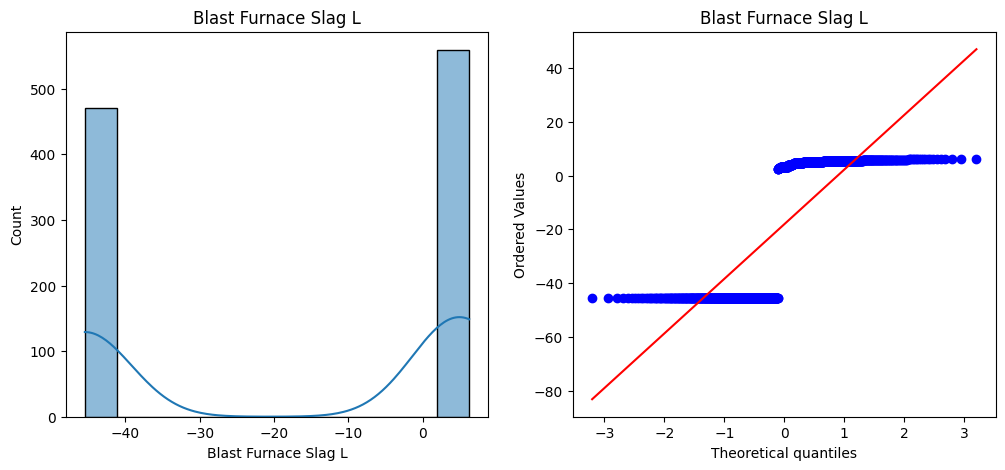

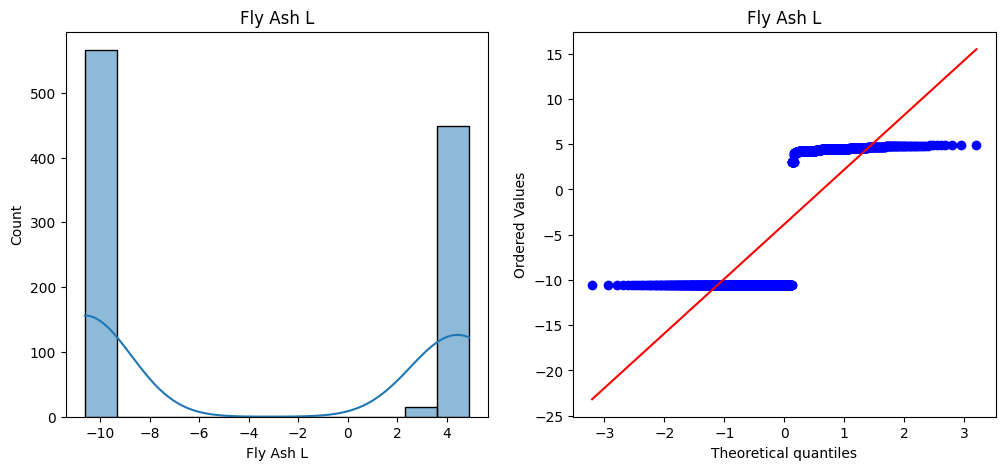

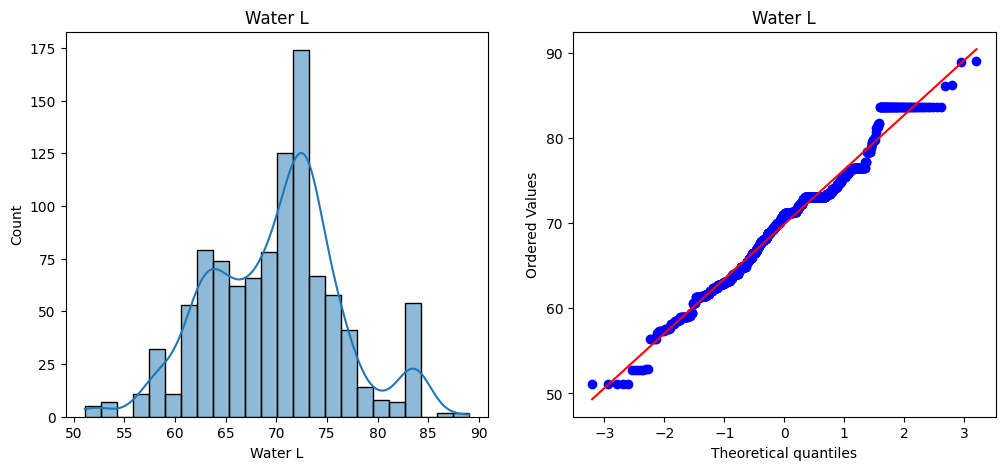

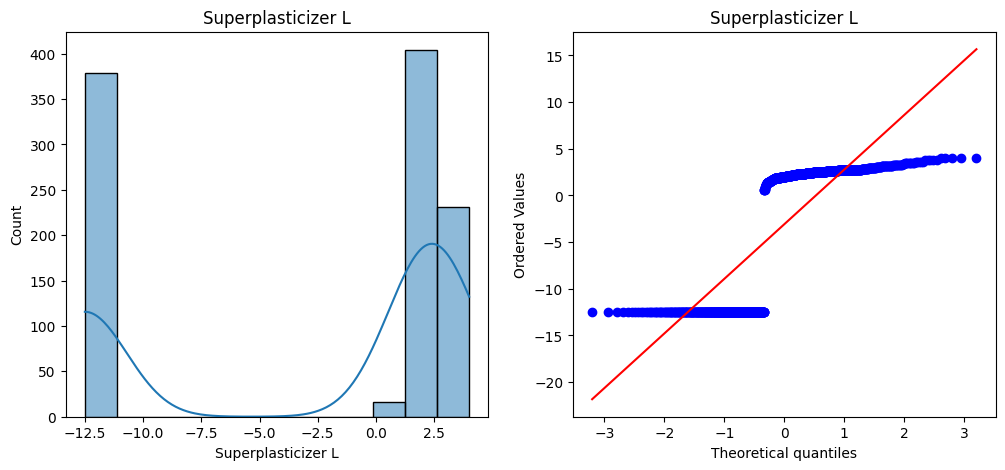

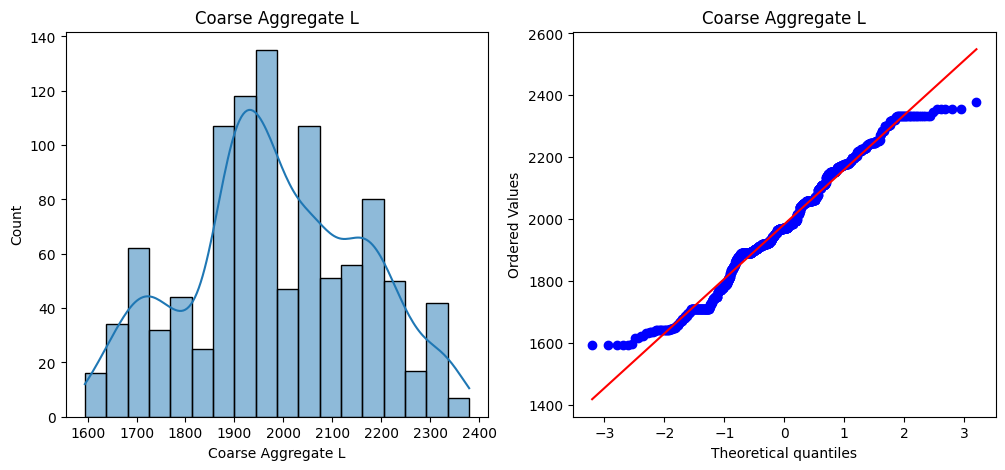

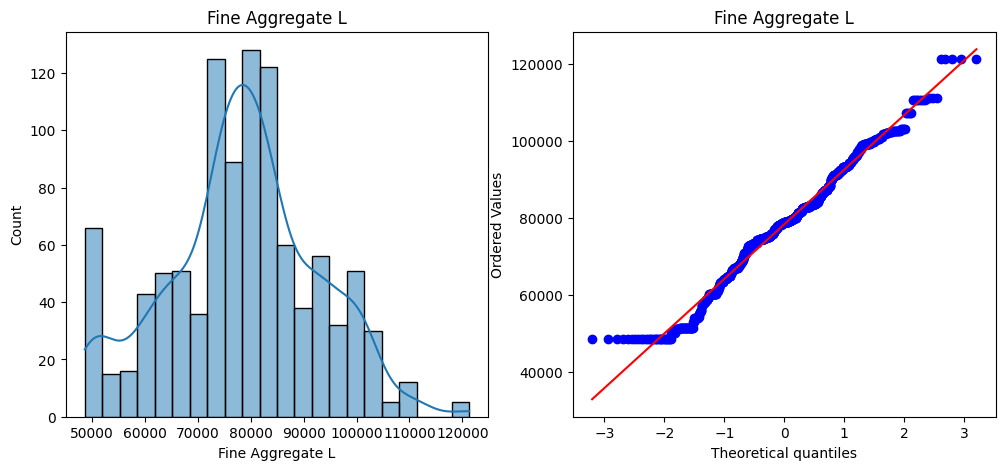

In [43]:
for i in df_new.columns:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(df_new[i], kde=True)
    plt.title(i)
    
    plt.subplot(122)
    stats.probplot(df_new[i], dist="norm", plot=plt)
    plt.title(i)
    plt.show()